In [2]:
import pandas as pd


In [3]:

pd.set_option("display.width",200)
pd.set_option("display.max_columns",20)

In [4]:
data_dir=("/Users/nifal/Documents/archive")

In [5]:

import os
print(os.listdir(data_dir))

['purchases.csv', 'products.csv', 'reviews.csv', 'interactions.csv', 'users.csv', 'sessions.csv']


In [6]:
users=pd.read_csv(f"{data_dir}/users.csv")

In [7]:
products=pd.read_csv(f"{data_dir}/products.csv")
sessions=pd.read_csv(f"{data_dir}/sessions.csv")
purchases=pd.read_csv(f"{data_dir}/purchases.csv")
reviews=pd.read_csv(f"{data_dir}/reviews.csv")
interactions=pd.read_csv(f"{data_dir}/interactions.csv")

In [8]:
tables={"users":users,"product":products,"sessions":sessions,"purchases":purchases,"reviews":reviews,"interactions":interactions}

In [9]:
print("=== SHAPE (rows,columns)===")
for name,df in tables.items():
    print(f"{name:13} {df.shape}")

=== SHAPE (rows,columns)===
users         (10000, 9)
product       (1000, 11)
sessions      (19315, 6)
purchases     (1737, 10)
reviews       (1253, 8)
interactions  (100000, 7)


In [10]:
print("\n===FIRST 3 ROWS OF users ===")
print(users.head(5))


===FIRST 3 ROWS OF users ===
                                user_id  age  gender country           city signup_date income_level      preferred_category loyalty_tier
0  8826d916-cdfb-41c6-81ff-91a761565a70   18  Female      US   Changchester  2026-02-05       medium       Sports & Outdoors       bronze
1  2416da6e-c212-4ddb-8d88-00160eb686b2   32  Female      AU  New Tammyfort  2025-03-03    very_high              Automotive       bronze
2  eb819333-b501-4c18-8c53-c786ed62c2f9   18    Male      US       Hullport  2025-03-12       medium                   Books       bronze
3  71445abc-2f0d-4ac2-8097-acb7a3823bc9   58  Female      US  Howardborough  2025-09-21          low  Beauty & Personal Care       bronze
4  13d16283-160e-4c20-aebd-f9d6297e4c73   38  Female      US    West Donald  2024-07-11       medium             Electronics       bronze


In [11]:
print("\n=== COLUMN TYPE OF USERS ===")
print (users.dtypes)


=== COLUMN TYPE OF USERS ===
user_id               object
age                    int64
gender                object
country               object
city                  object
signup_date           object
income_level          object
preferred_category    object
loyalty_tier          object
dtype: object


In [12]:
print ("\n=== MISSING VALUES (Only columns that have any) ===")
for name,df in tables.items():
    missing=df.isna().sum()
    missing = missing[missing>0]
    print(name,missing.to_dict() if len(missing) else "none")


=== MISSING VALUES (Only columns that have any) ===
users none
product {'rating_avg': 548}
sessions none
purchases none
reviews {'purchase_id': 200}
interactions none


In [13]:
print("\n=== KEY CHECKS ===")
print("users.user_id unique?      ", users["user_id"].is_unique)
print("purchases.user_id unique?  ", purchases["user_id"].is_unique)
print("every purchase user exists?", purchases["user_id"].isin(users["user_id"]).all())


=== KEY CHECKS ===
users.user_id unique?       True
purchases.user_id unique?   False
every purchase user exists? True


In [14]:
print("=== CONVERTING INTO DATES IN USERS ===")
print ("Before:",users["signup_date"].dtype)
users["signup_date"] = pd.to_datetime(users["signup_date"])
print("After:",users["signup_date"].dtype)

=== CONVERTING INTO DATES IN USERS ===
Before: object
After: datetime64[ns]


In [15]:
print (products.dtypes)

product_id              object
product_name            object
product_description     object
category                object
subcategory             object
brand                   object
price                  float64
rating_avg             float64
review_count             int64
stock_quantity           int64
date_added              object
dtype: object


In [16]:
print("=== CONVERTING INTO DATES IN PRODUCTS ===")
print("Before:",products["date_added"].dtype)
products["date_added"]=pd.to_datetime(products["date_added"])
print("After:",products["date_added"].dtype)
      

=== CONVERTING INTO DATES IN PRODUCTS ===
Before: object
After: datetime64[ns]


In [17]:
print (sessions.dtypes)

session_id         object
user_id            object
start_time         object
device_type        object
referrer_source    object
is_converted         bool
dtype: object


In [18]:
print("=== CONVERTING INTO DATES IN SESSIONS ===")
print ("Before:",sessions["start_time"].dtype)
sessions["start_time"]=pd.to_datetime(sessions["start_time"])
print("After:",sessions["start_time"].dtype)
                                
                                      

=== CONVERTING INTO DATES IN SESSIONS ===
Before: object
After: datetime64[ns]


In [19]:
purchases.dtypes

purchase_id        object
order_id           object
user_id            object
product_id         object
session_id         object
interaction_id     object
quantity            int64
unit_price        float64
total_amount      float64
order_date         object
dtype: object

In [20]:
print("=== CONVERTING INTO DATES IN PURCHESES ===")
print("Before:",purchases["order_date"].dtype)
purchases["order_date"]=pd.to_datetime(purchases["order_date"])
print("After:",purchases["order_date"].dtype)

=== CONVERTING INTO DATES IN PURCHESES ===
Before: object
After: datetime64[ns]


In [21]:
reviews.dtypes

review_id      object
user_id        object
product_id     object
purchase_id    object
rating          int64
title          object
review_text    object
review_date    object
dtype: object

In [22]:
print("=== CONVERTING INTO DATES IN REVIEWS ===")
print("Before:",reviews["review_date"].dtype)
reviews["review_date"]=pd.to_datetime(reviews["review_date"])
print("After:",reviews["review_date"].dtype)

=== CONVERTING INTO DATES IN REVIEWS ===
Before: object
After: datetime64[ns]


In [23]:
interactions.dtypes

interaction_id      object
user_id             object
product_id          object
session_id          object
interaction_type    object
timestamp           object
dwell_time_ms        int64
dtype: object

In [24]:
print("=== CONVERTING INTO DATES IN INTERACTIONS  ===")
print("Before:",interactions["timestamp"].dtype)
interactions["timestamp"]=pd.to_datetime(interactions["timestamp"])
print("After:",interactions["timestamp"].dtype)

=== CONVERTING INTO DATES IN INTERACTIONS  ===
Before: object
After: datetime64[ns]


In [25]:
for name, df, col in [("users", users, "signup_date"), ("products", products, "date_added"),
                      ("sessions", sessions, "start_time"), ("interactions", interactions, "timestamp"),
                      ("purchases", purchases, "order_date"), ("reviews", reviews, "review_date")]:
     print(f"{name:13} {df[col].min().date()}  ->  {df[col].max().date()}")

users         2023-01-02  ->  2026-05-31
products      2023-01-03  ->  2026-05-27
sessions      2023-01-04  ->  2026-05-31
interactions  2023-01-04  ->  2026-05-31
purchases     2023-01-15  ->  2026-05-31
reviews       2022-01-13  ->  2026-06-20


In [26]:
print("\n=== CHECKING DUPLICATES ===")
id_cols={"users": ["user_id"], "product": ["product_id"], "sessions": ["session_id"],
           "interactions": ["interaction_id"], "purchases": ["purchase_id", "interaction_id"],
           "reviews": ["review_id"]}
for name, df in tables.items():
    ids = id_cols[name]
    cols = df.columns.drop(ids)
    print(f"{name:13} rows={len(df):>7}  full dups={df.duplicated().sum():>4}  "
          f"dups ignoring IDs={df.duplicated(subset=cols).sum():>5}")


=== CHECKING DUPLICATES ===
users         rows=  10000  full dups=   0  dups ignoring IDs=    0
product       rows=   1000  full dups=   0  dups ignoring IDs=    0
sessions      rows=  19315  full dups=   0  dups ignoring IDs=    0
purchases     rows=   1737  full dups=   0  dups ignoring IDs=    0
reviews       rows=   1253  full dups=   0  dups ignoring IDs=    0
interactions  rows= 100000  full dups=   0  dups ignoring IDs= 3743


In [27]:

print("=== REMOVING DUPLICATES ===")
print("Rows before:", len(interactions))

cols_to_compare = interactions.columns.drop("interaction_id")
is_dup = interactions.duplicated(subset=cols_to_compare, keep="first")
print("Duplicate rows found:", is_dup.sum())

linked = interactions["interaction_id"].isin(purchases["interaction_id"])
print("Duplicates that a purchase points to:", (is_dup & linked).sum())

interactions = interactions[~is_dup].copy()
print("Rows after:", len(interactions))

print("Duplicates left:", interactions.duplicated(subset=cols_to_compare).sum())
print("Purchases still linked:", purchases["interaction_id"].isin(interactions["interaction_id"]).all())

=== REMOVING DUPLICATES ===
Rows before: 100000
Duplicate rows found: 3743
Duplicates that a purchase points to: 0
Rows after: 96257
Duplicates left: 0
Purchases still linked: True


In [28]:
products[products["rating_avg"].isna()][["product_name", "rating_avg", "review_count"]].head(3)

,product_name,rating_avg,review_count
0,The Elite Cipher - PlayStation 5 Edition,NaN,0
6,Introduction to Deep Learning,NaN,0
7,Apple Prime Prime5,NaN,0


In [29]:
pd.crosstab(products["rating_avg"].isna(), products["review_count"] == 0)

review_count,False,True
rating_avg,,
False,452,0
True,0,548


In [30]:
products["has_reviews"] = products["review_count"] > 0

In [31]:
print(products["has_reviews"].value_counts())

has_reviews
False    548
True     452
Name: count, dtype: int64


In [32]:

for name, df, col in [("users", users, "signup_date"), ("products", products, "date_added"),
                      ("sessions", sessions, "start_time"), ("interactions", interactions, "timestamp"),
                      ("purchases", purchases, "order_date"), ("reviews", reviews, "review_date")]:
    print(f"{name:13} {df[col].dtype}")
    

users         datetime64[ns]
products      datetime64[ns]
sessions      datetime64[ns]
interactions  datetime64[ns]
purchases     datetime64[ns]
reviews       datetime64[ns]


In [33]:
print("=== Revenue by Country ===")
pu_users=purchases.merge(users,on="user_id",how="left")
print(pu_users.groupby("country")["total_amount"].sum().sort_values(ascending=False).head(5).round(0).to_string())

=== Revenue by Country ===
country
US    44746.0
GB    12746.0
CA     8924.0
DE     7302.0
FR     6972.0


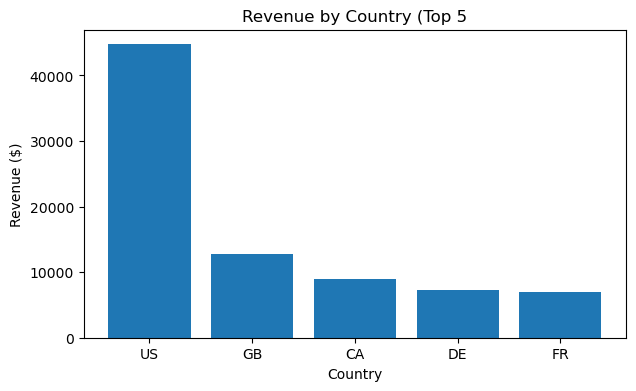

In [34]:
import matplotlib.pyplot as plt
top5 = pu_users.groupby("country")["total_amount"].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(7,4))
plt.bar(top5.index,top5.values)
plt.title("Revenue by Country (Top 5")
plt.xlabel("Country")
plt.ylabel("Revenue ($)")
plt.show()

=== Revenue by category ===
category
Electronics               40316.0
Sports & Outdoors         21001.0
Home & Kitchen            17713.0
Clothing & Accessories    15203.0
Automotive                10657.0
Books                      6865.0
Office Products            5638.0
Beauty & Personal Care     5571.0
Toys & Games               4292.0
Grocery & Gourmet          2255.0


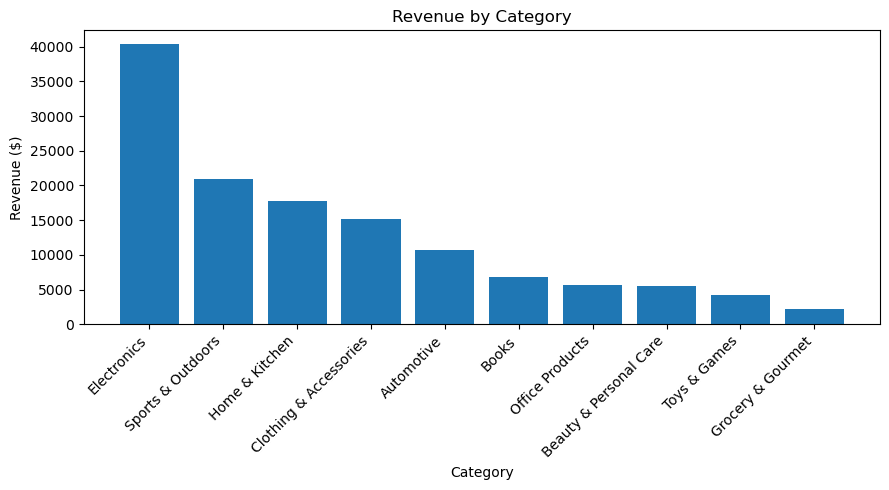

In [35]:
print("=== Revenue by category ===")
pu_prod=purchases.merge(products, on="product_id",how="left")
print(pu_prod.groupby("category")["total_amount"].sum().sort_values(ascending=False).round(0).to_string())
top_categories = pu_prod.groupby("category")["total_amount"].sum().sort_values(ascending=False)
plt.figure(figsize=(9,5))
plt.bar(top_categories.index,top_categories.values)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [36]:
print("\n=== Q10: Revenue by device type ===")
pu_sess = purchases.merge(sessions[["session_id","device_type","referrer_source"]], on="session_id", how="left")
print(pu_sess.groupby("device_type")["total_amount"].sum().sort_values(ascending=False).round(0).to_string())


=== Q10: Revenue by device type ===
device_type
mobile     74239.0
desktop    43686.0
tablet     11586.0


In [37]:
print("\n=== Q12: Top countries buying Electronics  ===")
master = (purchases.merge(users, on="user_id", how="left")
    .merge(products[["product_id","category"]], on="product_id", how="left"))
elec = master[master["category"] == "Electronics"]
print(elec.groupby("country")["total_amount"].sum().sort_values(ascending=False).head(5).round(0).to_string())


=== Q12: Top countries buying Electronics  ===
country
US    11228.0
GB     3774.0
FR     3485.0
CA     3446.0
JP     3109.0


In [38]:
print(" === High views, low purchases  ===")
views = interactions[interactions["interaction_type"]=="view"].groupby("product_id").size().rename("views")
buys  = purchases.groupby("product_id")["quantity"].sum().rename("purchased_qty")
vb = pd.concat([views, buys], axis=1).fillna(0)
vb = vb.merge(products[["product_id","product_name"]], on="product_id", how="left")
vb["view_to_buy_ratio"] = vb["views"] / vb["purchased_qty"].replace(0, 0.5)
print(vb.sort_values("views", ascending=False).head(5)[["product_name","views","purchased_qty"]].to_string(index=False))

 === High views, low purchases  ===
                              product_name  views  purchased_qty
                    Apple Accessorie Stand 3157.0           88.0
The Data Structures: A Comprehensive Guide 1833.0           84.0
        Instant Pot Microfiber Kitchenware 1551.0           55.0
           Wilson Book19 Fitness Equipment 1507.0           55.0
           Tommy Hilfiger Womenswear Dress 1391.0           44.0


In [39]:
print("=== Avg rating by category  ===")
rev_prod = reviews.merge(products[["product_id","category"]], on="product_id", how="left")
print(rev_prod.groupby("category")["rating"].mean().sort_values(ascending=False).round(2).to_string())

=== Avg rating by category  ===
category
Electronics               4.17
Home & Kitchen            4.16
Toys & Games              4.09
Books                     4.07
Grocery & Gourmet         4.05
Sports & Outdoors         4.05
Automotive                4.05
Beauty & Personal Care    4.03
Office Products           4.01
Clothing & Accessories    3.96


In [40]:
print("=== Avg rating by country ===")
rev_users = reviews.merge(users[["user_id","country"]], on="user_id", how="left")
print(rev_users.groupby("country")["rating"].mean().sort_values(ascending=False).head(5).round(2).to_string())

=== Avg rating by country ===
country
SE    4.49
SG    4.43
KR    4.29
AE    4.25
FR    4.24


In [41]:
print("\=== Avg spend, reviewers vs non-reviewers  ===")
reviewer_ids = set(reviews["user_id"].dropna())
per_user = purchases.groupby("user_id")["total_amount"].sum()
print("Reviewers avg total spend:    ", round(per_user[per_user.index.isin(reviewer_ids)].mean(), 2))
print("Non-reviewers avg total spend:", round(per_user[~per_user.index.isin(reviewer_ids)].mean(), 2))

\=== Avg spend, reviewers vs non-reviewers  ===
Reviewers avg total spend:     108.05
Non-reviewers avg total spend: 84.94


In [42]:
print("=== Conversion rate  ===")
print(round(sessions["is_converted"].mean()*100, 2), "%")

=== Conversion rate  ===
7.46 %


In [43]:
total_sessions     = sessions["session_id"].nunique()
view_sessions       = interactions.loc[interactions["interaction_type"] == "view", "session_id"].nunique()
click_sessions      = interactions.loc[interactions["interaction_type"] == "click", "session_id"].nunique()
cart_sessions        = interactions.loc[interactions["interaction_type"] == "add_to_cart", "session_id"].nunique()
purchase_sessions    = purchases["session_id"].nunique()

print("All sessions:    ", total_sessions)
print("Reached view:    ", view_sessions)
print("Reached click:   ", click_sessions)
print("Reached cart:    ", cart_sessions)
print("Reached purchase:", purchase_sessions)

All sessions:     19315
Reached view:     19315
Reached click:    11535
Reached cart:     8371
Reached purchase: 1440


In [44]:
click_from_view   = 11535 / 19315 * 100
print("click from view % :",click_from_view)
cart_from_click   =  8371 / 11535 * 100
print("cart_from_click % :",cart_from_click)
purchase_from_cart=  1440 /  8371 * 100
print("purchase_from_cart % :",purchase_from_cart)

click from view % : 59.72042454051255
cart_from_click % : 72.57043779800607
purchase_from_cart % : 17.20224584876359


In [45]:
print(interactions.loc[interactions["interaction_type"]=="add_to_cart","session_id"].isin(
      interactions.loc[interactions["interaction_type"]=="click","session_id"]).mean())

0.8052276559865092


In [46]:
def sessions_with(event):
    return interactions.loc[interactions["interaction_type"] == event, "session_id"].nunique()

In [47]:
funnel = pd.DataFrame({
    "stage": ["All sessions", "View", "Click", "Add to cart", "Purchase"],
    "sessions": [sessions["session_id"].nunique(), sessions_with("view"), sessions_with("click"),
                 sessions_with("add_to_cart"), purchases["session_id"].nunique()],
})

In [48]:
funnel["% of all sessions"] = (funnel["sessions"] / funnel["sessions"].iloc[0] * 100).round(1)

In [49]:
funnel["% of previous stage"] = (funnel["sessions"] / funnel["sessions"].shift(1) * 100).round(1)

In [50]:
print(funnel.to_string(index=False))

       stage  sessions  % of all sessions  % of previous stage
All sessions     19315              100.0                  NaN
        View     19315              100.0                100.0
       Click     11535               59.7                 59.7
 Add to cart      8371               43.3                 72.6
    Purchase      1440                7.5                 17.2


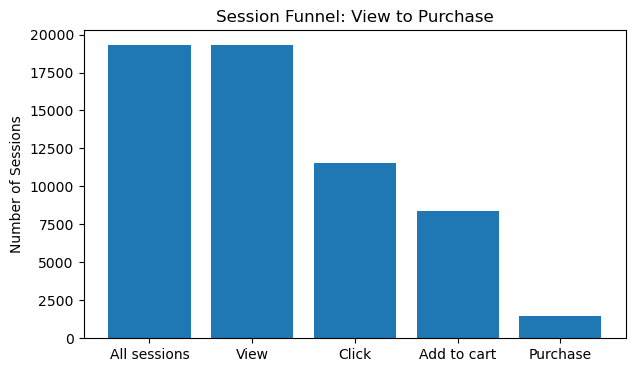

In [51]:
plt.figure(figsize=(7, 4))
plt.bar(funnel["stage"], funnel["sessions"])
plt.title("Session Funnel: View to Purchase")          # fill this in
plt.ylabel("Number of Sessions")         # fill this in
plt.show()

In [52]:
purchases.groupby(purchases["order_date"].dt.year)["total_amount"].agg(revenue="sum", orders="count")

,revenue,orders
order_date,,
2023,23610.80,308
2024,37103.90,502
2025,47738.66,643
2026,21057.49,284


In [53]:
purchases.groupby(purchases["order_date"].dt.year)["order_date"].agg(first="min", last="max")

,first,last
order_date,,
2023,2023-01-15 18:05:44.055402424,2023-12-29 19:16:52.917422033
2024,2024-01-01 21:33:25.063122923,2024-12-31 20:53:01.912876265
2025,2025-01-01 11:12:29.813881404,2025-12-31 14:52:06.510519009
2026,2026-01-01 22:58:36.326620786,2026-05-31 17:56:49.755253623


In [54]:
monthly = purchases.groupby(purchases["order_date"].dt.to_period("M"))["total_amount"].sum()

In [55]:
purchases.groupby(purchases["order_date"].dt.year)["total_amount"].mean()

order_date
2023    76.658442
2024    73.912151
2025    74.243639
2026    74.146092
Name: total_amount, dtype: float64

In [56]:
monthly = purchases.groupby(purchases["order_date"].dt.to_period("M"))["total_amount"].sum()
print("Best month:",monthly.idxmax(), monthly.max())   
print("Worst month:",monthly.idxmin(), monthly.min())   

Best month: 2025-06 5490.95
Worst month: 2023-01 197.24


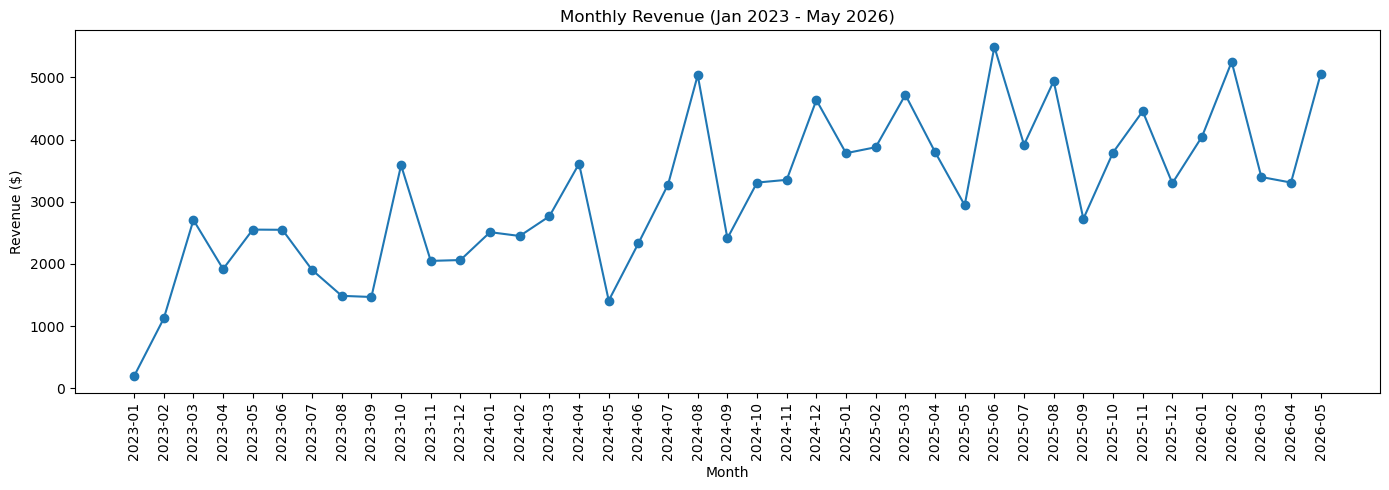

In [57]:
monthly = purchases.groupby(purchases["order_date"].dt.to_period("M"))["total_amount"].sum()


monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14, 5))


plt.plot(monthly.index, monthly.values, marker="o")


plt.title("Monthly Revenue (Jan 2023 - May 2026)")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [58]:
h1_2025 = monthly["2025-01":"2025-06"].mean()
h2_2025 = monthly["2025-07":"2025-12"].mean()
print("First half 2025 avg:", round(h1_2025, 0))
print("Second half 2025 avg:", round(h2_2025, 0))

First half 2025 avg: 4102.0
Second half 2025 avg: 3854.0


In [59]:
buyers = purchases["user_id"].nunique()
print(len(users), buyers, buyers/len(users)*100)

10000 1287 12.870000000000001


In [60]:
orders_per_user = purchases.groupby("user_id")["purchase_id"].count()
orders_per_user.value_counts().sort_index()

purchase_id
1    913
2    307
3     59
4      7
5      1
Name: count, dtype: int64

In [61]:
spend_per_user = purchases.groupby("user_id")["total_amount"].sum()
repeat_ids = orders_per_user[orders_per_user > 1].index
onetime_ids = orders_per_user[orders_per_user == 1].index
merged = purchases.merge(users[["user_id","loyalty_tier","income_level","age","gender"]], on="user_id", how="left")
merged.groupby("gender")["total_amount"].mean().round(2)

gender
Female               76.04
Male                 73.08
Non-binary           82.97
Prefer not to say    50.13
Name: total_amount, dtype: float64

In [62]:
merged["gender"].value_counts()

gender
Male                 856
Female               849
Non-binary            24
Prefer not to say      8
Name: count, dtype: int64

In [63]:
rev_by_prod = purchases.merge(products[["product_id","product_name"]], on="product_id", how="left")
rev_by_prod.groupby("product_name")["total_amount"].sum().sort_values(ascending=False).head(5)

product_name
Apple Accessorie Stand                8459.40
Apple Book4 Ultrabook                 7202.93
Wilson Book19 Fitness Equipment       5883.08
Instant Pot Microfiber Kitchenware    5218.45
Wilson Fitness Equipment Pro          3471.85
Name: total_amount, dtype: float64

In [64]:
sold_ids = set(purchases["product_id"])
never_sold = products[~products["product_id"].isin(sold_ids)]
print(len(never_sold), "of", len(products))

573 of 1000


In [65]:
products["price"].corr(products["rating_avg"])

np.float64(0.11091743134112499)

In [66]:
views = interactions[interactions.interaction_type=="view"].groupby("product_id").size().rename("views")
buys = purchases.groupby("product_id")["quantity"].sum().rename("purchased_qty")

vb = pd.concat([views, buys], axis=1).fillna(0)
vb["conversion_rate"] = (vb["purchased_qty"] / vb["views"] * 100).round(2)
vb.sort_values("views", ascending=False).head(5)

,views,purchased_qty,conversion_rate
product_id,,,
6e9b539a-77ad-4307-acb5-f558f8b5cc6f,3157.0,88.0,2.79
c1ab2206-9b50-4aaa-9446-f322d0976ea6,1833.0,84.0,4.58
eaaf2b74-b09a-4bf5-b0b2-09021044cab8,1551.0,55.0,3.55
58fd8edb-60ef-4856-bf1f-644ffc133d12,1507.0,55.0,3.65
1660a6f2-7ef5-4f47-a4aa-e917f41e014e,1391.0,44.0,3.16


In [67]:
review_counts = reviews.groupby("product_id").size()
print((review_counts < 5).sum(), "of", len(review_counts))

403 of 452


In [68]:
sessions.groupby("device_type").agg(sessions=("session_id","count"), conv_rate=("is_converted","mean"))

,sessions,conv_rate
device_type,,
desktop,6236,0.073926
mobile,11069,0.075255
tablet,2010,0.072637


In [69]:
sessions.groupby("referrer_source").agg(sessions=("session_id","count"), conv_rate=("is_converted","mean")).sort_values("conv_rate", ascending=False)

,sessions,conv_rate
referrer_source,,
display_ad,385,0.080519
paid_search,1509,0.080186
email,1888,0.076271
referral,1008,0.074405
direct,4742,0.074019
organic_search,6950,0.073813
social_media,2833,0.072361


In [70]:
chan = sessions.groupby("referrer_source").agg(sessions=("session_id","count"), conv_rate=("is_converted","mean"))
chan["converted_sessions"] = (chan["sessions"] * chan["conv_rate"]).round(0)

In [71]:
sessions.groupby(["device_type", "referrer_source"])["is_converted"].mean().round(4) * 100

device_type  referrer_source
desktop      direct              6.61
             display_ad          5.74
             email               7.46
             organic_search      7.25
             paid_search         8.90
             referral            8.24
             social_media        8.11
mobile       direct              7.85
             display_ad          9.82
             email               7.36
             organic_search      7.66
             paid_search         6.81
             referral            7.41
             social_media        6.90
tablet       direct              7.41
             display_ad          5.13
             email              10.00
             organic_search      6.34
             paid_search        11.88
             referral            4.95
             social_media        6.30
Name: is_converted, dtype: float64

In [75]:
master = purchases.merge(users, on="user_id", how="left")


In [76]:
master = master.merge(
    products[["product_id","product_name","category","subcategory","brand","price","rating_avg","has_reviews"]],
    on="product_id", how="left")

In [77]:
master = master.merge(
    sessions[["session_id","device_type","referrer_source"]],
    on="session_id", how="left")

In [78]:
master["order_year"] = master["order_date"].dt.year
master["order_month"] = master["order_date"].dt.to_period("M").astype(str)

In [79]:
orders_per_user = purchases.groupby("user_id")["purchase_id"].count()
master["customer_type"] = master["user_id"].map(
    lambda u: "Repeat" if orders_per_user.get(u, 0) > 1 else "One-time")

In [82]:
print("Shape:", master.shape)
print("Revenue check:", round(master["total_amount"].sum(), 2), "vs", round(purchases["total_amount"].sum(), 2))

Shape: (1737, 30)
Revenue check: 129510.85 vs 129510.85


In [84]:
master.to_csv("master_for_tableau.csv", index=False)